# LABORATORIO DE FÍSICA COMPUTACIONAL - 2º DTIE MATEMÁTICAS Y FÍSICA

<p style="text-indent: 0em; text-align: justify;">La física computacional emplea algoritmos y potencia de cálculo para resolver ecuaciones matemáticas complejas que describen el comportamiento de la naturaleza.

<p style="text-indent: 0em; text-align: justify;">Es indispensable para predecir fenómenos que son imposibles de recrear en laboratorios o de resolver manualmente, como la evolución de galaxias o el clima.

<p style="text-indent: 0em; text-align: justify;">Funciona como un laboratorio virtual, permitiendo testear teorías y diseñar tecnologías avanzadas de forma rápida, segura y extremadamente precisa. Para trabajar en esta asignatura utilizaremos Python como lenguaje de programación. Los ordenadores nos permiten resovler numéricamente problemas que de otra forma no podríamos resolver.

### Ejemplo: aproximación computacional a la integral
<p style="text-indent: 0em; text-align: justify;">Como ejemplo ilustrativo se pide aproximar la integral de Fresnel, que aparece de forma experimental en física óptica, por ejemplo.

$$I = \int_0^\pi \sin (x^2) dx$$

In [1]:
import math

def f(x):
    return math.sin(pow(x, 2))

intervalos = 1000
limite_inf = 0
limite_sup = math.pi

paso = (limite_sup - limite_inf) / intervalos

posicion_actual = limite_inf
valor_integral = 0

for i in range(intervalos):
    valor_integral += f(posicion_actual) * paso
    posicion_actual += paso

print(f"Valor final de la integral entre a = {limite_inf} y b = {limite_sup} de la función f: {valor_integral}")
    
    

Valor final de la integral entre a = 0 y b = 3.141592653589793 de la función f: 0.77332296340999


## Problema 1: El muelle simple. Aplicación de las leyes de Newton.

* [Ejemplo: aproximación computacional a la integral](#Ejemplo:-aproximación-computacional-a-la-integral)
* [Problema 1: El muelle simple](#Problema-1:-El-muelle-simple.-Aplicación-de-las-leyes-de-Newton.)
    * [Implementación en Python](#Implementación-en-Python)
    * [Demostración de la segunda derivada](#Ejercicio:-Demostración-de-la-segunda-derivada-mediante-límites)
    * [Generalización a fuerzas arbitrarias](#Generalización-a-fueras-arbitrarias)
    * [Conservación de la energía (muelle)](#Ejercicio:-¿Se-cumple-la-conservación-de-la-energía-para-el-muelle-unidimensional?)
    * [Algoritmo de Euler](#Algoritmo-de-Euler)
* [Modificaciones del método de Euler](#Modificaciones-del-método-de-Euler.)
    * [Elección del extremo derecho](#Elección-del-extremo-derecho)
    * [Algoritmo de Euler modificado](#Elección-de-un-extremo-izquierdo-y-un-extremo-derecho-(Algoritmo-de-Euler-modificado))
* [Comparación computacional de los métodos](#Comparación-computacional-de-los-métodos-de-Euler)
    * [Conservación de la energía](#Conservación-de-la-energía)
* [Explicación teórica Euler simple vs modificado](#Explicación-teórica-de-la-diferencia-Euler-simple-/-Euler-modificado)
* [Algoritmo de la diferencia centrada](#Algoritmo-de-la-diferencia-centrada)
    * [Desarrollo teórico](#Desarrollo-teórico)
    * [Aplicación al problema físico](#Aplicación-al-problema-físico)
* [El error computacional: errores de redondeo](#El-error-computacional:-errores-de-redondeo)

<p style="text-indent: 0em; text-align: justify;">Supongamos una particula de masa $m$ que se mueve unidimensionalmente a lo largo del eje $x$. Su posición en función del tiempo viene dada por la función $x(t)$. Supongamos que la particula está bajo los efectos de un muelle Newtoniano de constante $k$. Entonces la función posición deberá cumplir la EDO del muelle:

$$m\frac{d^2 x}{dt}(t) = -k x(t) \iff mx''(t) = -kx(t)$$

<p style="text-indent: 0em; text-align: justify;">La partícula se movera entre un tiempo inicial $t_i = t_0$ y un tiempo final $t_f = t_N$. Como solo podemos computar conjuntos discretos, estudiaremos la función posició en el intervalo $\Delta t = t_f - t_i$ dividido en $N$ partes equiespaciadas 
$t_0, t_1, t_2, ..., t_N$. Es decir, no podemos determinar la función $x(t)$ completa, pero si podemos determinar su valor en los $N$ intervalos equiespaciados de $\Delta t$. 

<p style="text-indent: 0em; text-align: justify;">Por la ecuación del muelle y escribiendo la aceleración como:
$$x''(t) = \lim_{h \to 0} \frac{x(t+h)-2x(t) +x(t-h))}{h^2}$$

<p style="text-indent: 0em; text-align: justify;">Conseguimos una expresión computacional para la aceleración. Así, en la ecuación del muelle:
    
$$mx''(t_i) = -kx(t_i)$$
<p style="text-indent: 0em; text-align: justify;">Sin embargo no podemos utilizar la definición de la aceleración de forma exacta (los ordenadores no pueden computar límties de forma exacta) pero sí podemos aproximarla como:
    
$$x''(t_i) \approx \frac{x(t_{i+1}) - 2x(t_i) + x(t_{i+1})}{\Delta t^2}$$
<p style="text-indent: 0em; text-align: justify;">Entonces, en la ecuación del muelle:
    
$$m \frac{x(t_{i+1}) - 2x(t_i) + x(t_{i+1})}{\Delta t^2} \approx -kx(t_i)$$
<p style="text-indent: 0em; text-align: justify;">Que se corresponde con $N-1$ ecuaciones, una por cada $t_i$ (porque no puedo aplicar la ecuación en $t_0$ ni en $t_N$ porque no puedo aplicar la ecuación en estos dos instantes de tiempo: solo puedo aplicar la fórmula de la aproximación en el interior del $\Delta t$. Si además denotamos por simplicidad $x(t_i) := x_i$, el problema se reduce a resolver el sistema:

$$
\begin{equation}
\begin{cases}
x_{i+1} - 2x_i + x_{i-1} = -\frac{k}{m}\Delta t^2 x_i \iff x_{i+1} + \left(\frac{k}{m} \Delta t^2 - 2\right)x_i + x_{i-1} = 0\}_{i=1,\dots,N-1} 
\end{cases}
\end{equation}
$$
El problema para este sistema es que tenemos $N+1$ incógnitas $t_0, t_1, \dots, t_N$ y tan solo $N-1$ ecuaciones. Por suerte de la EDO:
$$mx''(t) = -kx(t) \implies x(t) = A\cos(\omega t) \pm B\sin(\omega t)$$
No puedo resolver el problema solo con esta EDO, sino que tenemos que establecer las condiciones iniciales para el problema.
$$
\begin{equation}
\begin{cases}
x(t_0 = 0) = x_0 \\
x'(t_0 = 0) = v_0
\end{cases}
\end{equation}
$$
Con estas condiciones iniciales, automáticamente reducimos las incógnitas de $N+1$ a $N$ (porque conocemos el valor de $x_0$). Todavía necesito una ecuación extra para reducir las incógnitas a $N-1$ (que es el número de ecuaciones que tengo). Con las condiciones iniciales, en particular con $v_0$. Por la definición de derivada (y en particular de velocidad):  
$$v_0 \approx \frac{x_1 - x_0}{\Delta t}$$
Si $\Delta t$ es suficientemente pequeña, podemos modelar la poisición como:
$$x(t+h) = x(t) + x'(t)h + \frac{1}{2!}x''(t)h^2 + \cdots$$
En particular si centramos el desarrollo en $t_0$ con $h = \Delta t$ tendré $$ x_1 = x_0 + v_0 \Delta t + \frac{1}{2}x''(0)\Delta t ^2 = x_0 + v_0 \Delta t - \frac{1}{2}\frac{kx_0}{m}\Delta t ^2 = x_0 + v_0\Delta t - \frac{k}{2m}x_0\Delta t^2$$
Que nos da la ecuación que faltaba para conseguir las $N+1$ ecuaciones que resuelven el problema. Entonces, el problema consiste en resolver:

### Implementación en Python

In [2]:
# VALORES INICIALES DEL PROBLEMA
k = 1 # N / m
masa = 1 # g

tinicial = 0  # sec
xinicial = 10 #cm
vinicial = 0  # m/s

tfinal = 18
N = 100

delta = (tfinal - tinicial) / N

# Inicialización para los dos primeros valores
x0 = xinicial
v0 = vinicial

# x1 mediante Taylor: x(t+h) ≈ x(t) + h*v(t) + (h^2/2)*a(t)
x1 = x0 + v0 * delta - (k / (2 * masa)) * x0 * (delta**2)

output = [x0, x1]

# Usamos N-1 porque ya tenemos 2 puntos y queremos llegar al paso N
for i in range(1, N):
    xsiguiente = (2 - (k / masa) * (delta**2)) * output[i] - output[i-1]
    output.append(xsiguiente)

# Salida (limitada para no inundar la consola)
for i in range(len(output)):
    print(f"{i}: {output[i]}")


# CONFIGURACIÓN PARA CENTRAR GRÁFICOS EN TODO EL DOCUMENTO
from IPython.display import display, HTML
display(HTML("""
<style>
.jp-OutputArea-child {
    display: flex;
    justify-content: center;
}
</style>
"""))


0: 10
1: 9.838
2: 9.357248799999997
3: 8.573322738879996
4: 7.511621021020282
5: 6.206542782079511
6: 4.700372556999364
7: 3.0419102610724362
8: 1.2848900726867623
9: -0.5137605540539627
10: -2.2957653388433394
11: -4.003387326654192
12: -5.581299565081448
13: -6.978377697600065
14: -8.14935639271644
15: -9.056295940708802
16: -9.6698115002222
17: -9.9700251671284
18: -9.947210018619637
19: -9.602105265507598
20: -8.945892301793114
21: -7.999832427500534
22: -6.7945779825569375
23: -5.369179210978496
24: -3.7698190329643513
25: -2.0483167182821616
26: -0.26044894192762946
27: 1.5358573801453579
28: 3.2824019231016357
29: 4.92259664374942
30: 6.403299233139723
31: 7.676534927376299
32: 8.701050889965883
33: 9.443652803720571
34: 9.880280366634713
35: 9.996786845669892
36: 9.789397430905366
37: 9.264831539379507
38: 8.440085105977753
39: 7.341879915142318
40: 6.0057978150562725
41: 4.4751278657624045
42: 2.799463773617834
43: 1.0330970552080458
44: -0.7667420077904832
45: -2.541738629736

Podemos graficar la solución:

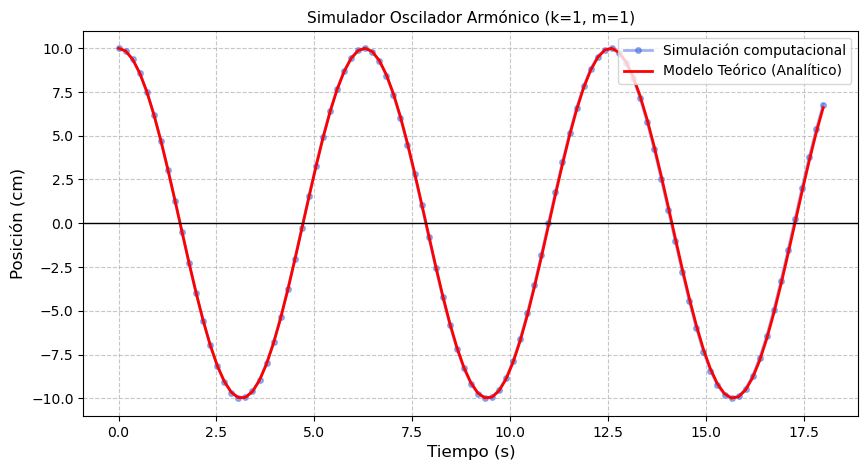

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Cálculo de la frecuencia angular teórica
omega = np.sqrt(k / masa)

# Definición del tiempo
tiempo = np.arange(len(output)) * delta

# Configuración de la gráfica
plt.figure(figsize=(10, 5))

# 1. Simulación (Puntos azules)
plt.plot(tiempo, output, label='Simulación computacional', color='royalblue', linewidth=2, marker='o', markersize=4, alpha=0.5)

# 2. MODELO TEÓRICO (Línea roja)
# Usamos la fórmula: x(t) = xinicial * cos(omega * t)
x_teorica = xinicial * np.cos(omega * tiempo)
plt.plot(tiempo, x_teorica, label='Modelo Teórico (Analítico)', 
         color="red", linewidth=2, linestyle='-')

# Estética de la gráfica
plt.title(f"Simulador Oscilador Armónico (k={k}, m={masa})", fontsize=11)
plt.xlabel("Tiempo (s)", fontsize=12)
plt.ylabel("Posición (cm)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=1) 
plt.legend()

plt.show()

Podemos incluso determinar el periodo del péndulo para así no calcular ningún dato inecesario (hacer cálculos consume recursos). Así si $t_f \gt T$ solo será necesario calcular las iteradas hasta $T$. Otra de las mejoras posibles es calcular $N$ en función de una resolución dada, que no sea simplemente un parámetro fijo.

In [4]:
import math

# VALORES INICIALES DEL PROBLEMA
k = 1 # N / m
masa = 0.01 # kg

tinicial = 0  # sec
xinicial = 10 #cm
vinicial = 0  # m/s

tfinal = 100

# Para calcular N en función de la resolución dada
puntos_por_segundo = 10

# Calculo el periodo del sistema 
periodo = 2 * math.pi * math.sqrt(masa / k)
tiempo_optimo = min(tfinal - tinicial, periodo / 2) # Periodo entre dos porque un periodo es "ir y venir"
N = max(int(puntos_por_segundo * tiempo_optimo), 2)
delta = tiempo_optimo / N 

# Inicialización para los dos primeros valores
x0 = xinicial
v0 = vinicial

# x1 mediante Taylor: x(t+h) ≈ x(t) + h*v(t) + (h^2/2)*a(t)
x1 = x0 + v0 * delta - (k / (2 * masa)) * x0 * (delta**2)

output = [x0, x1]

# Usamos N-1 porque ya tenemos 2 puntos y queremos llegar al paso N
c = (k / masa) * (delta**2)
for i in range(1, N):
    xsiguiente = (2 - c) * output[i] - output[i-1]
    output.append(xsiguiente)

# Salida (limitada para no inundar la consola)
for i in range(len(output)):
    print(f"{i}: {output[i]}")


0: 10
1: 4.516886443839246
2: -5.919547370692251
3: -9.864471098308062


### Ejercicio: Demostración de la segunda derivada mediante límites

<p style="text-indent: 0em; text-align: justify;">Problema para casa (para el doble grado). Sea $x: I \subseteq \mathbb{R} \to \mathbb{R}$ dos veces diferenciable (derivable), entonces:

$$x''(t) = \lim_{h \to 0} \frac{x(t+h) - 2x(t) + x(t-h)}{h^2} \quad \forall t \in \mathring{I}$$


<p style="text-indent: 0em; text-align: justify;">La prueba es sencilla con la regla de L'Hôpital. Para un $t \in \mathring{I}$:

$$
\begin{aligned}
& \lim_{h \to 0} h^{-2} (x(t+h) - 2x(t) + x(t-h)) \\ \\
= & \lim_{h \to 0}    \frac{\frac{d}{d h} [x(t+h) - 2x(t) + x(t-h)]}{\frac{d}{d h} h^2} \\\\
= & \lim_{h \to 0}  \frac{x'(t+h) - x'(t-h)}{2h} \\\\
= & \lim_{h \to 0} (2h)^{-1} (x'(t+h) - x'(t) + \underbrace{x'(t) - x'(t-h)}_{=0}) \\\\
= & \frac{1}{2} \lim_{h \to 0} \left( \frac{x'(t+h) - x'(t)}{h} + \frac{x'(t) - x'(t-h)}{h} \right) \\\\
\overset{\text{def}}{=} & \frac{1}{2} (x''(t) + \lim_{h \to 0} \frac{x'(t) - x'(t-h)}{h}) \overset{\text{*}}{=} \frac{1}{2} [2x''(t)] = x''(t)
\end{aligned}
$$

(*) Cálculo auxiliar (es la derivada con paso inferior en vez de superior), donde tomamos $k := -h$:

$$
\begin{aligned}
\lim_{h \to 0} & \frac{x'(t) - x'(t-h)}{h} \\
= \lim_{h \to 0} & \frac{-[x'(t-h) - x'(t)]}{h} \\
\text{hacemos } k = -h \implies & \lim_{k \to 0} \frac{x'(t+k) - x'(t)}{k} \\
\overset{\text{def}}{=} & x''(t)
\end{aligned}
$$

$\square$

### Generalización a fuerzas arbitrarias
<p style="text-indent: 0em; text-align: justify;">¿Y si la fuerza que actúa sobre la particula no es la fuerza dada por la Ley de Hook? Supongamos una particula que se mueve en una dimensión bajo el efecto de una fuerza arbitraria que denotaremos por $F$.
    
$$m\frac{d^2x(t)}{dt^2} = F(x)$$
<p style="text-indent: 0em; text-align: justify;">Podemos describir esta ecuacion como:
    
$$F(x) = -\frac{dV(x)}{dx}$$
<p style="text-indent: 0em; text-align: justify;">Donde el potencial se entiende como la energía que almacena un cuerpo por estar en un campo de fuerzas. 

<p style="text-indent: 0em; text-align: justify;">Este potencial verificará la Ley de Conservación de la energía: una ley fundamental de la física que dice que la energía ni se crea ni se destruye. En un sistema aislado, la cantidad de energía permanece constante a lo largo del tiempo. 

$$\frac{1}{2} m \left(\frac{dx(t)}{dt}\right)^2 + V(x(t)) = constante = k$$
<p style="text-indent: 0em; text-align: justify;">Que desde las Ecuaciones diferenciales se entiende como la integral primera:
    
$$\frac{1}{2} m \left(x'(t)\right)^2 + V(x(t)) = constante = k$$

> <p style="text-indent: 0em; text-align: justify;">Dada la EDO $$x'(t) = f(x, t)$$ una integral primera es una función $$E:\Omega \subset \mathbb{R}^2 \longrightarrow \mathbb{R}$$ de forma que para cualquier solución de la EDO $$x: I \subset  \mathbb{R} \longrightarrow \mathbb{R}$$verifica:$$E(x(t), t) = E = \text{ constante  } \forall t \in I$$

<p style="text-indent: 0em; text-align: justify;">Donde la velocidad viene dada (numéricamente) como:
$$x'(t_i) \approx \frac{x(t_{i+1}) - x_i}{\Delta t}$$

### Ejercicio: ¿Se cumple la conservación de la energía para el muelle unidimensional?


<p style="text-indent: 0em; text-align: justify;">Para demostrar que la energía se conserva, definimos la Energía Mecánica Total ($E$) como la suma de la Energía Cinética ($T$) y la Energía Potencial ($V$):
$$E(t) = T(t) + V(t) = \frac{1}{2} m v(t)^2 + \frac{1}{2} k x(t)^2$$
<p style="text-indent: 0em; text-align: justify;">Para probar que $E(T) = E$ es una constante, su derivada respecto al tiempo debe ser igual a cero:
$$\frac{dE}{dt} = m \cdot v(t) \cdot \frac{dv(t)}{dt} + k \cdot x(t) \cdot \frac{dx(t)}{dt} = v(t) \cdot \left[m\cdot \frac{dv(t)}{dt} + k \cdot x(t) \right] v(t) \cdot \left[m\cdot a(t) + k \cdot x(t) \right]$$
<p style="text-indent: 0em; text-align: justify;">Además por la segunda Ley de Newton:
$$m \cdot a(t) = -k \cdot x(t) \implies m \cdot a(t) + k \cdot x(t) = 0$$
<p style="text-indent: 0em; text-align: justify;">Sustituyendo esta igualdad en nuestra derivada:
$$\frac{dE}{dt} = 0$$
<p style="text-indent: 0em; text-align: justify;">Como la variación de la energía respecto al tiempo es nula, concluimos que la energía total es constante:
$$E_{total} = \text{constante}$$

### Algoritmo de Euler
<p style="text-indent: 0em; text-align: justify;">Podemos plantear un algoritmo diferente para comprobar (computacionalmente) que la Energía se conserva. Utilizaremos un algoritmo nuevo para para calcular simultáneamente la posición y la velocidad

<p style="text-indent: 0em; text-align: justify;">Supongamos una partícula que se mueve bajo la acción de una fuerza que depende únicamente de la posición de la partícula. La 2ª Ley de Newton se traduce directamente en la siguiente Ecuación ordinaria de segundo grado. $$m\ddot{x} = F(x)$$Con F(x) una fuerza conocida. El objetivo es traducir el problema para no tener que calcular segundas derivadas. Consideremos la reducción del sistema:
$$\begin{cases}v(t) = \dot{x}(t)\\a(t) = \dot{v}(t) = \ddot{x}(t) = \frac{1}{m} F(x(t))\end{cases}$$

<p style="text-indent: 0em; text-align: justify;">Donde ahora las incógnitas son $\{x(t), v(t)\}$ (hemos introducido una nueva incógnita para simplificar el problema)

> <p style="text-indent: 0em; text-align: justify;">Imaginemos que tuviéramos una ecuación diferencial de orden $n$ en lugar de orden $2$. El método estándar es transformar la EDO original en un sistema de $n$ ecuaciones, todas ellas de primer orden.

<p style="text-indent: 0em; text-align: justify;">Como en el planteamiento del problema del muelle, trabajaremos con una partición de puntos $$\{t_i = t_0 < t_1 < t_2 < \dots < t_{N-1} < t_N = t_f\}$$

<p style="text-indent: 0em; text-align: justify;">Que no tiene necesariamente que ser homogénea. Si aplicamos el Teorema del valor medio, sabemos que para cada $i$:

$$x(t_{i+1}) - x(t_i) = \dot{x}(\xi_i) (t_{i+1} - t_i)$$


$$v(t_{i+1}) - v(t_i) = \dot{v}(\eta_i) (t_{i+1} - t_i)$$

<p style="text-indent: 0em; text-align: justify;">Donde $\eta_i$ y $\xi_i$ son puntos intermedios $$t_{i} < \xi_i, \eta_i < t_{i+1}$$

<p style="text-indent: 0em; text-align: justify;">Para el **Algoritmo de Euler** tomaremos $$\boxed{\xi_i = \eta_i = t_i}$$

<p style="text-indent: 0em; text-align: justify;">Con esta aproximación :

$$\begin{cases}\dot{x}(t) = v(t)\\v'(t) = \frac{1}{m}F(x(t))\end{cases} \iff \begin{cases}x_{i+1} = x_i  + v_i\Delta t\\
v_{i+1} = v_i + \frac{1}{m}F(x_i)\Delta t\end{cases}$$

In [5]:
# VALORES INICIALES DEL PROBLEMA
k = 1 # N / m
masa = 0.010 # g

tinicial = 0  # sec
xinicial = 10 #cm
vinicial = 0  # m/s

tfinal = 2
N = 100

delta = (tfinal - tinicial) / N

x0 = xinicial
v0 = vinicial

In [6]:
output_x = [x0]
output_v = [v0]

def fuerza(posicion):
    return - k * posicion
    
for i in range(N):
    # 1. a = F/m
    aceleracion = fuerza(output_x[i]) / masa
    
    # 2. xi+1 = xi + vi * delta
    xsiguiente = output_x[i] + output_v[i] * delta
    
    # 3. vi+1 = vi + (F/m) * delta  
    vsiguiente = output_v[i] + aceleracion * delta
    
    output_x.append(xsiguiente)
    output_v.append(vsiguiente)

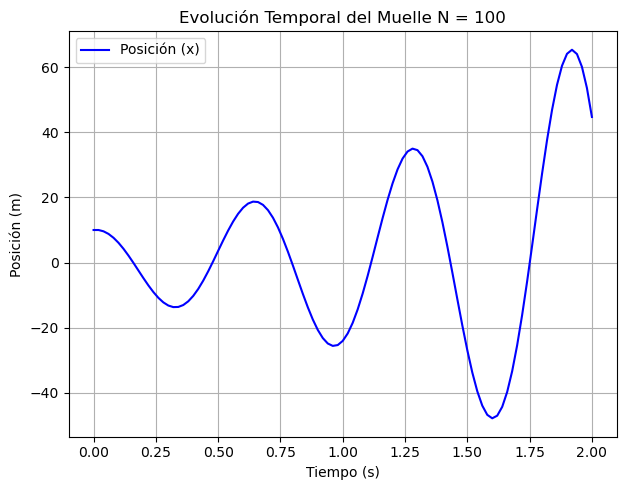

In [7]:
# Creamos un array de tiempo para el eje X de las gráficas
tiempo = np.linspace(tinicial, tfinal, len(output_x))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tiempo, output_x, label='Posición (x)', color='blue')
plt.title(f"Evolución Temporal del Muelle N = {N}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición (m)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<p style="text-indent: 0em; text-align: justify;">Es muy interesante cómo ver como la amplitud no se mantiene constante. El algoritmo de Euler es mucho peor que el de la derivada segunda para el mismo coste de cálculo. El problema es el mismo que el del algoritmo de la derivada segunda pero con $N=100$ vemos una amplificación total de la amplitud. Si tomamos $N = 10000$ los errores se refinan.

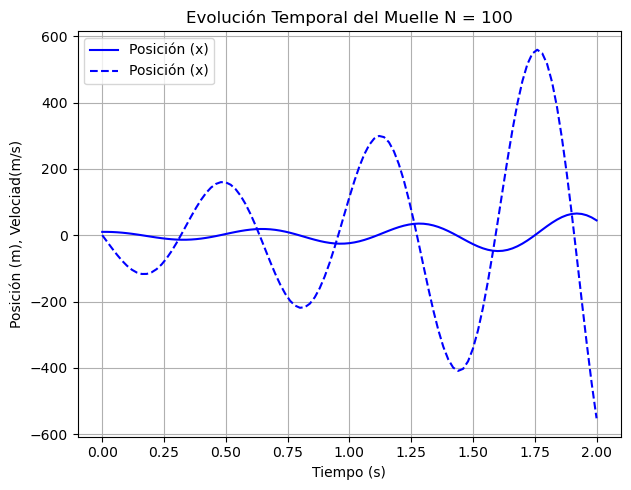

In [8]:
delta = (tfinal - tinicial) / N


output_x = [x0]
output_v = [v0]

for i in range(N):
    aceleracion = fuerza(output_x[i]) / masa
    xsiguiente = output_x[i] + output_v[i] * delta
    vsiguiente = output_v[i] + aceleracion * delta
    output_x.append(xsiguiente)
    output_v.append(vsiguiente)

tiempo = np.linspace(tinicial, tfinal, len(output_x))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(tiempo, output_x, label='Posición (x)', color='blue')
plt.plot(tiempo, output_v, "--", label='Posición (x)', color='blue')

plt.title(f"Evolución Temporal del Muelle N = {N}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición (m), Velociad(m/s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<p style="text-indent: 0em; text-align: justify;">El Algoritmo de Euler tiene más itneres teórico que interés práctico. Necesita un coste de cálculo descomunal.

### Modificaciones del método de Euler.

#### Elección del extremo derecho

<p style="text-indent: 0em; text-align: justify;">Si en lugar de aproximar por el Algoritmo de Euler:
$$\xi_i = \eta_i = t_i$$
<p style="text-indent: 0em; text-align: justify;">Aproximamos los valores intermedios del Teorema del Valor Medio por $$\xi_i = \eta_i = t_{i+1}$$
<p style="text-indent: 0em; text-align: justify;">A la hora de programarlo, es mucho más difícil: no puedo sacar $x_{i+1}$ sin tener $v_{i+1}$, pero no puedo tener $v_{i+1}$ sin tener $F(x_{i+1})$


#### Elección de un extremo izquierdo y un extremo derecho (Algoritmo de Euler modificado)

<p style="text-indent: 0em; text-align: justify;">Tomemos, por ejemplo:
$$\boxed{\xi_i = t_{i+1}\text{   ;   }\eta_i = t_{i}} $$
Entonces las ecuaciones computacionales serán:

$$\begin{cases}x_{i+1} = x_i  + v_{i+1}\Delta t\\
v_{i+1} = v_i + \frac{1}{m}F(x_i)\Delta t\end{cases}$$
<p style="text-indent: 0em; text-align: justify;">Y empezando por la segunda ecuación, podemos calcular computacionalmente las posiciones y velocidades

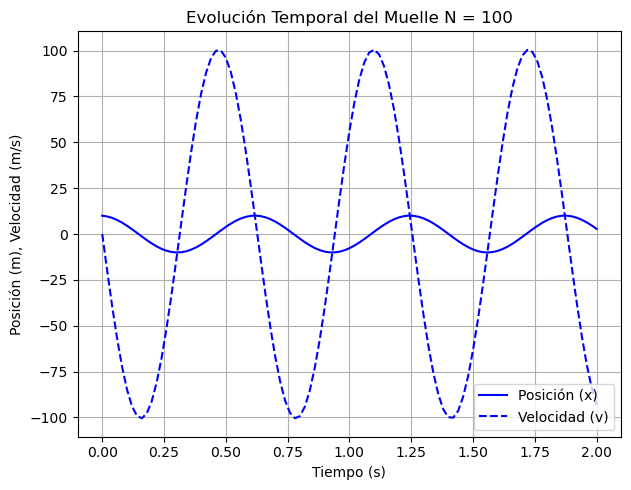

In [9]:
delta = (tfinal - tinicial) / N


output_x = [x0]
output_v = [v0]

for i in range(N):
    # 1. Calculamos la aceleración en el punto actual x[i]
    aceleracion = fuerza(output_x[i]) / masa
    
    # 2. ACTUALIZO PRIMERO LA VELOCIDAD (v_{i+1})
    # v_{i+1} = v_i + a * delta
    vsiguiente = output_v[i] + aceleracion * delta
    
    # 3. ACTUALIZAMOS LA POSICIÓN USANDO LA VELOCIDAD RECIÉN CALCULADA (v_{i+1})
    # x_{i+1} = x_i + v_{i+1} * delta
    xsiguiente = output_x[i] + vsiguiente * delta
    
    output_x.append(xsiguiente)
    output_v.append(vsiguiente)

tiempo = np.linspace(tinicial, tfinal, len(output_x))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(tiempo, output_x, label='Posición (x)', color='blue')
plt.plot(tiempo, output_v, "--", label="Velocidad (v)", color="blue")
plt.title(f"Evolución Temporal del Muelle N = {N}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición (m), Velocidad (m/s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Comparación computacional de los métodos de Euler

<p style="text-indent: 0em; text-align: justify;">Podemos programar un código que muestre las diferencias entre los distintos modelos del Algoritmo de Euler. Para este propósito, compararemos el algoritmo de Euler tradicional con el algoritmo de Euler modificado (elección de un extremo izquierdo y uno derecho).



In [10]:
def algoritmo_euler(tinicial, tfinal, N, x0, v0):
    delta = (tfinal - tinicial) / N

    output_x = [x0]
    output_v = [v0]
    
    for i in range(N):
        aceleracion = fuerza(output_x[i]) / masa
        xsiguiente = output_x[i] + output_v[i] * delta
        vsiguiente = output_v[i] + aceleracion * delta
        output_x.append(xsiguiente)
        output_v.append(vsiguiente)

    return output_x, output_v

def algoritmo_euler_modificado(tinicial, tfinal, N, x0, v0):
    delta = (tfinal - tinicial) / N


    output_x = [x0]
    output_v = [v0]
    
    for i in range(N):
        aceleracion = fuerza(output_x[i]) / masa
        vsiguiente = output_v[i] + aceleracion * delta
        xsiguiente = output_x[i] + vsiguiente * delta
        
        output_x.append(xsiguiente)
        output_v.append(vsiguiente)

    return output_x, output_v

In [11]:
def graficar_algoritmos_euler_frente_euler_modificado(N):
    """Mismas condiciones inciales para un mismo número de operaciones N"""
    x_euler, v_euler = algoritmo_euler(tinicial, tfinal, N, xinicial, vinicial)
    x_euler_mod, v_euler_mod = algoritmo_euler_modificado(tinicial, tfinal, N, xinicial, vinicial)

    tiempo = np.linspace(tinicial, tfinal, len(x_euler))
    
    plt.figure(figsize=(12, 6))
    
    plt.plot(tiempo, x_euler, label='Algoritmo de Euler simple', color='red')
    plt.plot(tiempo, v_euler, "--", label="Velocidad algoritmo de Euler simple", color="red")
    plt.plot(tiempo, x_euler_mod, label='Algoritmo de Euler modificado', color='blue')
    plt.plot(tiempo, v_euler_mod, "--", label="Velocidad algoritmo de Euler modificado", color="blue")

    
    plt.title(f"Comparación de Algoritmos (N = {N} pasos)")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Posición (m), Velocidad (m/s)")
    plt.axhline(0, color='black', lw=1) # Línea de equilibrio
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.show()

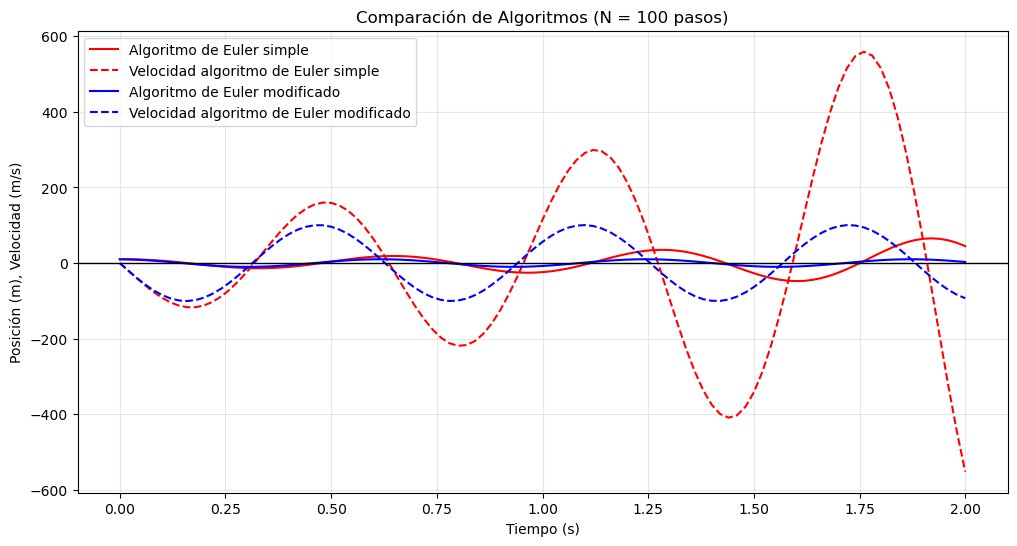

In [12]:
graficar_algoritmos_euler_frente_euler_modificado(100)

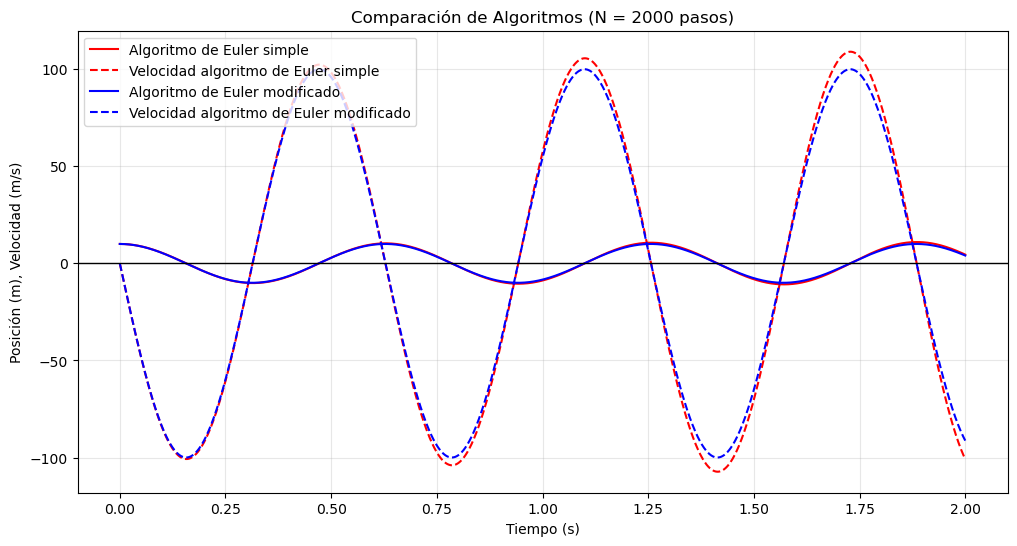

In [13]:
graficar_algoritmos_euler_frente_euler_modificado(2000)

#### Conservación de la energía

<p style="text-indent: 0em; text-align: justify;">Podemos comprobar el principio de conservación de la energía de forma computacional. Con $N = 100$ se ven los defectos del Algoritmo de Euler sin modificar.

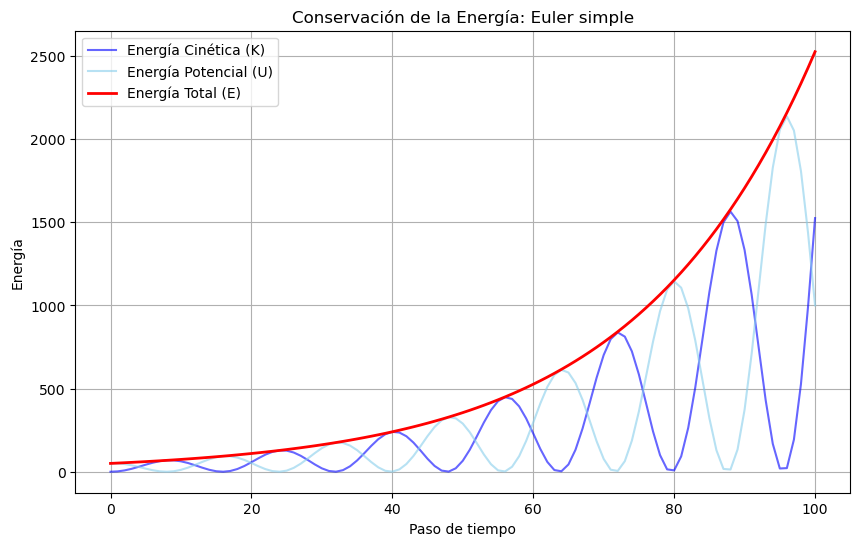

Energía inicial: 50.00000
Energía final:   2525.24741
Diferencia:      2475.24741


In [14]:
posiciones, velocidades = algoritmo_euler(tinicial, tfinal, 100, x0, v0) 
cinetica = [0.5 * masa * v**2 for v in velocidades]
potencial = [0.5 * k * x**2 for x in posiciones]
energia_total = [c + p for c, p in zip(cinetica, potencial)]

plt.figure(figsize=(10, 6))
plt.plot(cinetica, label="Energía Cinética (K)", color='blue', alpha=0.6)
plt.plot(potencial, label="Energía Potencial (U)", color='skyblue', alpha=0.6)
plt.plot(energia_total, label="Energía Total (E)", color='red', linewidth=2)

plt.title("Conservación de la Energía: Euler simple")
plt.xlabel("Paso de tiempo")
plt.ylabel("Energía")
plt.legend()
plt.grid(True)
plt.show()

# Verificación numérica
print(f"Energía inicial: {energia_total[0]:.5f}")
print(f"Energía final:   {energia_total[-1]:.5f}")
print(f"Diferencia:      {abs(energia_total[-1] - energia_total[0]):.5f}")

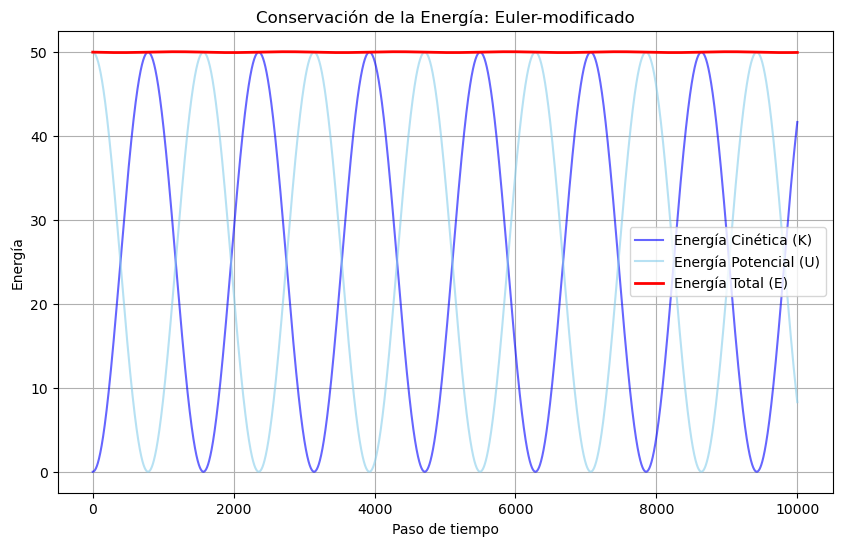

Energía inicial: 50.00000
Energía final:   49.96283
Diferencia:      0.03717


In [15]:
 
posiciones, velocidades = algoritmo_euler_modificado(tinicial, tfinal, 10000, x0, v0) # Aumento la N para que se vea bien la conservación
cinetica = [0.5 * masa * v**2 for v in velocidades]
potencial = [0.5 * k * x**2 for x in posiciones]
energia_total = [c + p for c, p in zip(cinetica, potencial)]

plt.figure(figsize=(10, 6))
plt.plot(cinetica, label="Energía Cinética (K)", color='blue', alpha=0.6)
plt.plot(potencial, label="Energía Potencial (U)", color='skyblue', alpha=0.6)
plt.plot(energia_total, label="Energía Total (E)", color='red', linewidth=2)

plt.title("Conservación de la Energía: Euler-modificado")
plt.xlabel("Paso de tiempo")
plt.ylabel("Energía")
plt.legend()
plt.grid(True)
plt.show()

# Verificación numérica
print(f"Energía inicial: {energia_total[0]:.5f}")
print(f"Energía final:   {energia_total[-1]:.5f}")
print(f"Diferencia:      {abs(energia_total[-1] - energia_total[0]):.5f}")

### Explicación teórica de la diferencia Euler simple / Euler modificado
#### Comprobación Algoritmo de Euler sin modificar: 
Computacionalmente el Algoritmo de Euler simple se escribe como:
$$\begin{cases}x_{i+1} = x_i  + v_i\Delta t \iff x_{i+1} - x_i = + v_i\Delta t \\
v_{i+1} = v_i + \frac{1}{m}F(x_i)\Delta t\end{cases}$$

<p style="text-indent: 0em; text-align: justify;"> Equivalentemente, cambiando los  índices: 


$$\begin{cases}x_{i} = x_{i-1}  + v_{i-1}\Delta t \iff x_{i} - x_{i-1} = + v_{i-1}\Delta t \\
v_{i} = v_{i-1} + \frac{1}{m}F(x_{i-1})\Delta t\end{cases}$$

Restando las dos primeras ecuaciones:

$$x_{i+1} - 2x_i + x_{i+1} = (v_i - v_{i+1})\Delta t \implies \frac{x_{i+1} - 2x_i + x_{i-1}}{\Delta t^2} = \frac{1}{m}F(x_{i-1})$$

<p style="text-indent: 0em; text-align: justify;"> De donde se deduce:

$$x''(t_i) \approx \frac{1}{m} F(x_{i-1}$$

<p style="text-indent: 0em; text-align: justify;"> Que es una aproximación (mala) de la Segunda Ley de Newton (porque querríamos que la aceleración coincidiera en el mismo instante con la fuerza)

#### Comprobación Algortitmo de Euler modificado

$$\begin{cases}x_{i+1} = x_i  + v_{i+1}\Delta t \iff x_{i+1} - x_i = + v_{i+1}\Delta t \\
v_{i+1} = v_i + \frac{1}{m}F(x_i)\Delta t\end{cases}$$

<p style="text-indent: 0em; text-align: justify;"> O equivalentemente:

$$\begin{cases}x_{i} = x_{i-1}  + v_{i}\Delta t \iff x_{i} - x_{i-1} = + v_{i}\Delta t \\
v_{i} = v_{i-1} + \frac{1}{m}F(x_{i-1})\Delta t\end{cases}$$

<p style="text-indent: 0em; text-align: justify;"> De nuevo, restando las dos primeras ecuaciones:
    
$$x_{i+1} - 2x_i + x_{i-1} = (v_{i+1} - v_i) \Delta t = \frac{1}{m} F(x_i) \Delta t^2$$

<p style="text-indent: 0em; text-align: justify;">Pero entonces, análogamente al apartado anterior:
    
$$x''(t_i) \approx \frac{1}{m}F(x_i)$$

<p style="text-indent: 0em; text-align: justify;">Que resulta una aproximación notablemente mejor de la Segunda Ley de Newton. Esto explica la diferencia entre ambos algoritmos.

### Algoritmo de la diferencia centrada 

#### Desarrollo teórico

No solo podemos aproximar el cociente incremental de la derivada por la izquierda o por la derecha. 

$$\frac{f(t) - f(t-\Delta t)}{\Delta t} \approx f'(t) \approx \frac{f(t+\Delta t) - f(t)}{\Delta t}$$

Podemos considerar también la aproximación central:

$$f'(t) \approx \frac{f(t+\frac{\Delta t}{2}) - f(t - \frac{\Delta t}{2})}{\Delta t}$$

Que converge en $\Delta t \to 0$ más rápido que las aproximaciones por la derecha o por la izquierda. Tomando los restos por la izquierda y por la derecha

$$R_i(t) = \frac{f(t) - f(t-\Delta t)}{\Delta t}  - f'(t)$$
$$R_d(t) = \frac{f(t + \Delta t) - f(t)}{\Delta t}  - f'(t)$$

Así como el resto centrado:

$$R_c(t) = \frac{f(t+\frac{\Delta t}{2}) - f(t - \frac{\Delta t}{2})}{\Delta t} - f(t)$$

Entonces decir que la aproximación por diferencias centradas es equivalente a decir:

$$\lim_{\Delta t \to 0} \frac{R_c(t)}{R_i(t)} = \lim_{\Delta t \to 0} \frac{R_c(t)}{R_d(t)} = 0$$

#### Aplicación al problema físico

<p style="text-indent: 0em; text-align: justify;">Ahora mismo tenemos la partición de instantes de tiempo ${t_i}$. Podemos considerar una nueva partición que incluya los puntos medios. Así entre $t_{i-1} y t_{i+1}$:

$$t_{i-1} < t_{i-\frac{1}{2}} < t_i < t_{i+\frac{1}{2}} < t_{i+1}$$

<p style="text-indent: 0em; text-align: justify;">Vamos a calcular las velocidades en los puntos $i \pm \frac{1}{2}$ y calcularemos las posiciones en los puntos $i$. Esto supone un incremento de coste computacional. Así, utilizando la aproximación de diferencia centrada podemos aproximar la velocidad y la posición como:

$$\begin{cases}v_{i+\frac{1}{2}} = \frac{x_{i+\frac{1}{2}} - x_{i-\frac{1}{2}}}{\Delta t}\\
F_i = ma_i = m\cdot \frac{v_{i+\frac{1}{2}} - v_{i-\frac{1}{2}}}{\Delta t}\end{cases}$$

O equivalentemente, en la versión que usaremos en la implementación:

$$\boxed{\begin{cases} 
x_{i+1} = x_i + v_{i+\frac{1}{2}} \cdot \Delta t \\ 
v_{i+\frac{1}{2}} = v_{i-\frac{1}{2}} + a_i \cdot \Delta t = v_{i-\frac{1}{2}} + \frac{F_i}{m} \cdot \Delta t
\end{cases}}$$

Restando ambas ecuaciones:

$$x_{i+1} - 2x_i + x_{i-1} = (v_{i+\frac{1}{2}} - v_{i-\frac{1}{2}}) * \Delta t = \frac{1}{m} F(x_i) \Delta t^2$$

De donde se deduce que el método de las diferencias centradas tiene el mismo orden de convergencia que el método de Euler modificado, cosa que vemos experimentalmente en la siguiente implementación:

In [16]:
def algoritmo_diferencia_centrada(tinicial, tfinal, N, x0, v0):
    
    delta = (tfinal - tinicial) / N

    # Inicializo valores
    output_x = [x0]
    output_v = [ v0 + (delta * fuerza(x0)) / (masa * 2) ]
    x_actual = output_x[0]
    v_actual = output_v[0]

    # Calculos previos al bucle
    fuerza_inicial = fuerza(x_actual)
    aceleracion_inicial = fuerza_inicial / masa
    v_media = v_actual + aceleracion_inicial * (delta / 2) # Calculo v0.5

    for i in range(N):
        # De la ecuación (1): x(i+1) = x(i) + v(i+0.5)*delta 
        output_x.append(output_x[i] + v_media*delta)
        # De la ecuación (2): [ ( F(i)*delta )  / m ] + v(i-0.5) = v(i+0.5)
        v_media +=  (fuerza(output_x[i+1]) / masa) * delta
        output_v.append(v_media)

    return output_x, output_v

In [17]:
def graficar_algoritmos_euler_frente_centrada(N):
    """Mismas condiciones inciales para un mismo número de operaciones N
    Grafica el Algoritmo de Euler frente el Algoritmo de las diferencias centradas."""
    x_euler, v_euler = algoritmo_euler(tinicial, tfinal, N, xinicial, vinicial)
    x_centr, v_centr = algoritmo_diferencia_centrada(tinicial, tfinal, N, xinicial, vinicial)

    tiempo_x = np.linspace(tinicial, tfinal, len(x_euler))
    tiempo_v = tiempo_x + (delta / 2)
    
    plt.figure(figsize=(12, 6))

    plt.plot(tiempo_x, x_euler, label="Posicion Euler simple", color="red")
    # la velocidad en el metodo de euler usa los mismos puntos de la particion temporal que la posición (los enteros)
    plt.plot(tiempo_x, v_euler, "--", label="Velocidad Euler simple", color="red")
    # Lo mismo ocurre con la posición en el Método de las diferencias centradas
    plt.plot(tiempo_x, x_centr, label='Posición Diferencias centradas', color='purple')
    # Pero la velocidad de las diferencias centradas están en una segunda partición fraccionaria
    plt.plot(tiempo_v, v_centr, '--', label='Velocidad Diferencias centradas', color='purple')
        
    plt.title(f"Comparación de Algoritmos (N = {N} pasos)")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Posición (m), Velocidad (m/s)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.show()

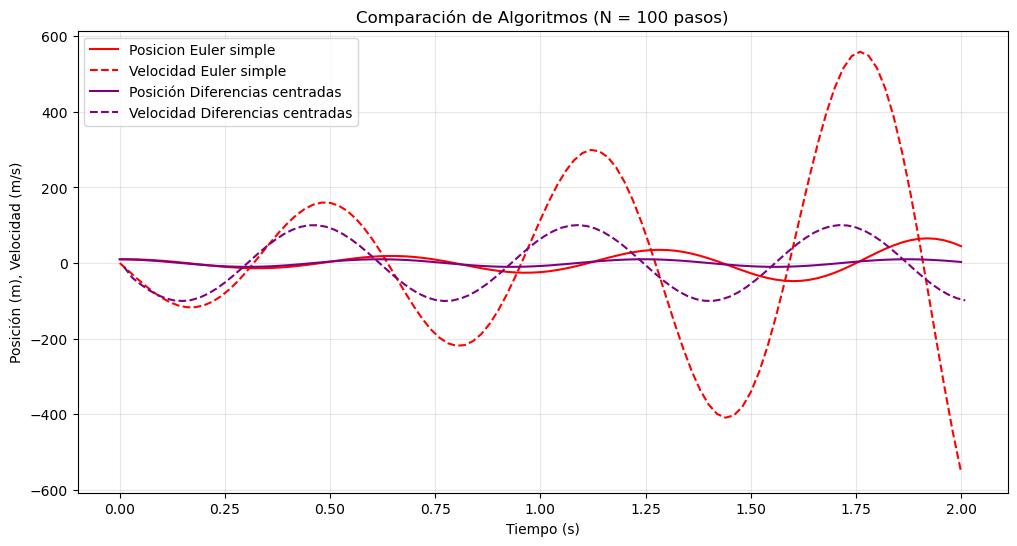

In [18]:
graficar_algoritmos_euler_frente_centrada(100)

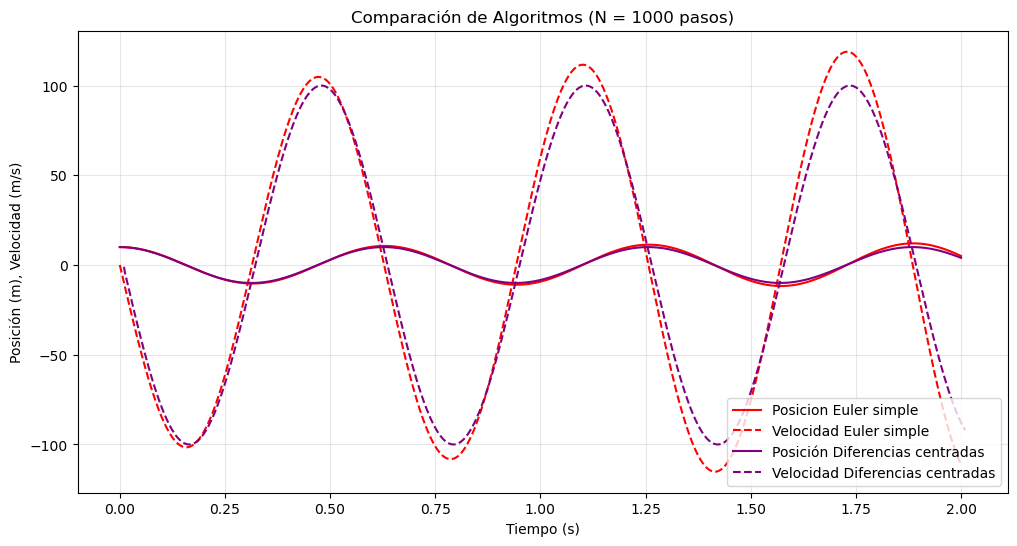

In [19]:
graficar_algoritmos_euler_frente_centrada(1000)

### El error computacional: errores de redondeo

<p style="text-indent: 0em; text-align: justify;">Los ordenadores además de errores de truncamiento, presentan errores de redondeo (un ordenador de 64 bits tiene 2^64 posiciones decimales en binario). Por ejemplo, si analizamos la convergencia de sucesiones tipo:

$$x_{n+2} + Ax_{n+1} + Bx_n = C$$

Diferentes procesadores presentan diferentes valores para la posición $N$ de la sucesión!

In [20]:
def siguiente(xi, xj, A, B, C):
    """xi = x_n, xj = x_n+1"""
    return -A* xj - B*xi + C

def calcular_sucesion(N, A, B, C, x0, x1):
    output_x = [x0, x1]
    for i in range(N-2):
        x_siguiente = siguiente(output_x[i], output_x[i+1], A, B, C)
        output_x.append( x_siguiente )
    return output_x

calcular_sucesion(N=20, A=-19/3, B=2, C=-10, x0=2, x1=8/3)

[2,
 2.6666666666666665,
 2.8888888888888857,
 2.962962962962944,
 2.9876543209875415,
 2.9958847736618743,
 2.9986282578834533,
 2.999542752604789,
 2.999847584063424,
 2.9999491938587752,
 2.9999830596453947,
 2.999994323369947,
 2.999997928718873,
 2.9999982351463004,
 2.9999929651554886,
 2.9999589756921594,
 2.999754249072698,
 2.9985256260760984,
 2.9911538003365585,
 2.946922816646005]

Un décimo en binario tiene una representación infinita. Los errores de truncamiento hacen que $10 \cdot \frac{1}{10}$ no sea uno:

In [21]:
sum = 0
for i in range(10):
    sum += 1/10
print(f"10 * 0/10 = {sum}")

10 * 0/10 = 0.9999999999999999


Otros números, que si tienen representación finita en el sistema binario como $\frac{1}{16}$ no presentan errores de redondeo:

In [22]:
sum = 0
for i in range(16):
    sum += 1/16
print(f"16 * 1/16 = {sum}")

16 * 1/16 = 1.0


Más información en "Numerical Algorithms and Digital Representation by Knut Morken"

## Problema 2: Modelización del oscilador anarmónico

* [La importancia del oscilador armónico](#La-importancia-del-oscilador-armónico)
* [El Periodo del Oscilador Anarmónico](#El-Periodo-del-Oscilador-Anarmónico)
* [Ejercicio: calcular el periodo del oscilador anarmónico...](#Ejercicio:-calcular-el-periodo-del-oscilador-anarmónico...)
* [Aplicación de algoritmos para la resolución numérica...](#Aplicación-de-algoritmos-para-la-resolución-numérica...)
    * [Método de Euler para resolver EDOS](#Método-de-Euler-para-resolver-EDOS)
    * [¿Por qué transformar una EDO en un Sistema?](#¿Por-qué-transformar-una-EDO-en-un-Sistema?)
    * [El proceso de derivación](#El-proceso-de-derivación)
    * [Construcción del Sistema Equivalente](#Construcción-del-Sistema-Equivalente)
    * [Implementación del Algoritmo de Euler para la resolución...](#Implementación-del-Algoritmo-de-Euler-para-la-resolución...)
    * [Implementación Computacional: El Algoritmo de...](#Implementación-Computacional:-El-Algoritmo-de...)
    * [Resolución Analítica del problema de valores iniciales...](#Resolución-Analítica-del-problema-de-valores-iniciales...)
          
Un oscilador anarmónico es un oscilador donnde la fuerza no sigue la Ley de Hook $F(x) = -kx^3$

In [23]:
# VALORES INICIALES DEL PROBLEMA 2
k = 1 # N / m
masa = 0.010 # kg

tinicial = 0  # sec
xinicial = 0.1 #cm
vinicial = 0  # m/s

tfinal = 50
N = 10000

delta = (tfinal - tinicial) / N

x0 = xinicial
v0 = vinicial

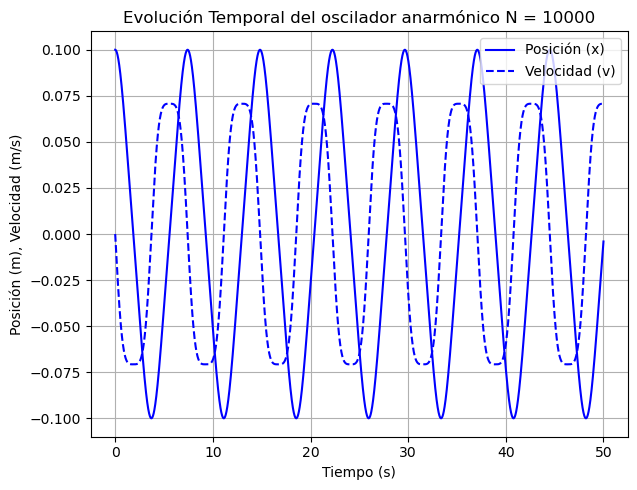

In [24]:
def fuerza(posicion):
    return -k * pow(posicion, 3)

output_x, output_v = algoritmo_euler_modificado(tinicial, tfinal, N=N, x0=x0, v0=v0)

tiempo = np.linspace(tinicial, tfinal, len(output_x))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(tiempo, output_x, label='Posición (x)', color='blue')
plt.plot(tiempo, output_v, "--", label="Velocidad (v)", color="blue")
plt.title(f"Evolución Temporal del oscilador anarmónico N = {N}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición (m), Velocidad (m/s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [25]:

# Energía cinética igual que para el oscilador armónico
cinetica = 0.5 * masa * np.array(output_v)**2
# Energía potencial: U = 1/4 * k * x^4 (integrar la fuerza)
potencial = 0.25 * k * np.array(output_x)**4
# Energía total (Mecánica): E = K + U
energia_total = cinetica + potencial


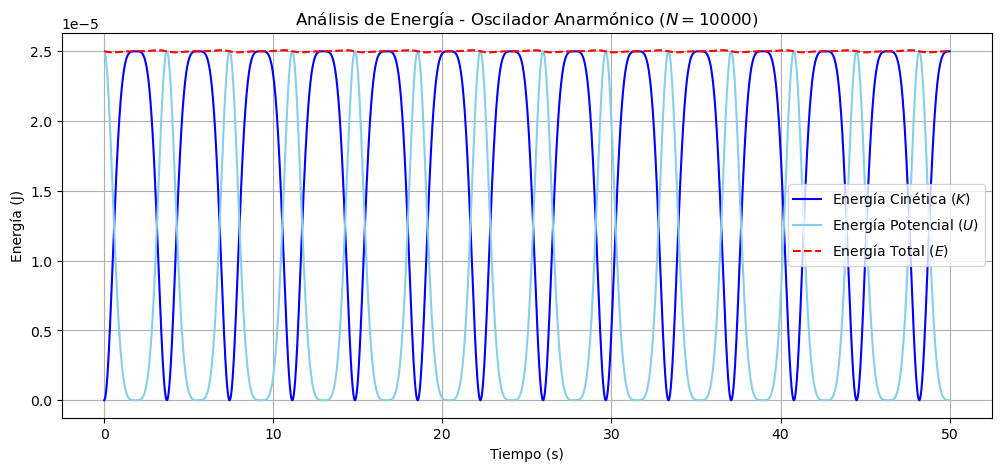

Desviación máxima de energía: 7.65261945059607e-08


In [26]:
plt.figure(figsize=(12, 5))
plt.plot(tiempo, cinetica, label='Energía Cinética ($K$)', color='blue')
plt.plot(tiempo, potencial, label='Energía Potencial ($U$)', color='skyblue')
plt.plot(tiempo, energia_total, label='Energía Total ($E$)', color='red', linestyle='--')

plt.title(f"Análisis de Energía - Oscilador Anarmónico ($N={N}$)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Energía (J)")
plt.legend()
plt.grid(True)
plt.show()

# Opcional: Mostrar la desviación de la energía para verificar la conservación
error_energia = np.abs(energia_total - energia_total[0])
print(f"Desviación máxima de energía: {np.max(error_energia)}")

### La importancia del oscilador armónico
<p style="text-indent: 0em; text-align: justify;">Se puede demostrar que **el oscilador armónico es una primera aproximación a cualquier movimiento cerca de un punto de equilibrio estable**. Supongamos una fuerza que solo depende de la posición de la partícula, y sea $x_0$ el punto de equilibrio de energía potencial. Entonces, por Desarrollos de Taylor: 

$$F(x) \approx F(x_0) + F'(x_0)(x-x_0)$$

<p style="text-indent: 0em; text-align: justify;">Si necesitamos más precisión podemos tomar términos de orden superior. Por ejemplo, si la primera derivada se anulara en el equilibrio 
    
$$F'(x_0) = 0$$

<p style="text-indent: 0em; text-align: justify;">No podemos tomar exclusivamente el término de primer orden (estaríamos "borrando" el problema). Supongamos por ejemplo: 

$$F'(x_0) = 0 \quad F''(x_0) \not = 0$$

<p style="text-indent: 0em; text-align: justify;">Entonces el desarrollo de Taylor quedaría como:

$$F(x) \approx F(x_0) + \frac{1}{2}F'(x_0)(x-x_0)^2$$

<p style="text-indent: 0em; text-align: justify;">Dependiendo del signo de la primera derivada que no se anula, $$F^{\alpha}(x_0) \quad \alpha \in \mathbb{N}$$Entonces podemos estudiar el signo de la fuerza $F$ en torno al punto $x_0$. Por ejemplo si $F'(x_0) > 0 \implies F$ creciente en un entorno $V_{x_0}$ y por tanto la fuerza será negativa a la izquierda del punto $x_0$ y positiva a la derecha del punto $x_0$ Para una fuerza $F(x)$ donde $F(x_0) = 0$, la estabilidad se determina mediante la primera derivada de orden $n$ que no se anula en dicho punto ($F^{(n)}(x_0) \neq 0$).


###### 1. Si $n$ es impar (1, 3, 5...)
<p style="text-indent: 0em; text-align: justify;">El comportamiento depende del signo de la derivada:

* Estable: $F^{(n)}(x_0) < 0$  (La fuerza es restauradora; se opone al desplazamiento).
* Inestable: $F^{(n)}(x_0) > 0$  (La fuerza es repulsiva; acelera la partícula lejos del equilibrio).

##### 2. Si $n$ es par (2, 4, 6...)
* Inestable: Siempre que $F^{(n)}(x_0) \neq 0$.  (Representa un punto de inflexión. El sistema es estable por un lado pero inestable por el otro).

##### Relación con la Energía Potencial $U(x)$

<p style="text-indent: 0em; text-align: justify;">Dado que $F(x) = -\frac{dU}{dx}$, el análisis se traslada al potencial de la siguiente forma:
    
$$F^{(n)}(x_0) = -U^{(n+1)}(x_0)$$

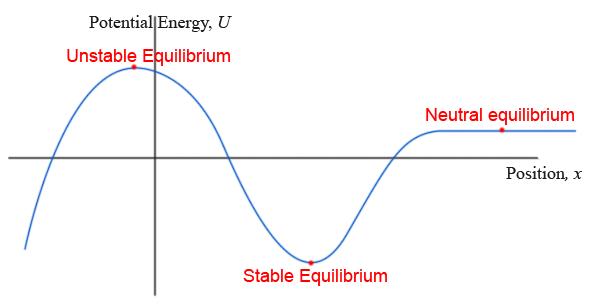



<p style="text-indent: 0em; text-align: justify;">Esta es la razón por la cual el **oscilador armónico** es uno de los pilares fundamentales de la física. Cuando un sistema se desplaza ligeramente de su posición de equilibrio estable $x_0$, la fuerza restauradora tiende a devolverlo a dicho punto. Al llegar a $x_0$, la partícula tiene una velocidad máxima que la hace "pasarse" de largo, generando un ciclo de ida y vuelta que se repite indefinidamente (en ausencia de fricción).

<p style="text-indent: 0em; text-align: justify;">Como en el equilibrio $U'(x_0) = 0$, y para desplazamientos pequeños los términos de orden superior son despreciables, el sistema se comporta como:
    
1. Un potencial cuadrático: $U(x) \propto \Delta x^2$
2. Una fuerza lineal: $F(x) = -k\Delta x$ (Ley de Hooke)

<p style="text-indent: 0em; text-align: justify;">No importa cuán compleja sea la fuerza original; si el equilibrio es estable y el desplazamiento es pequeño, el sistema "creerá" que es un muelle y oscilará con un movimiento armónico simple.

### El Periodo del Oscilador Anarmónico

Para un sistema con una fuerza del tipo $F(x) = -kx^3$ (que corresponde a un potencial $U(x) = \frac{1}{4}kx^4$), el periodo de oscilación viene dado por:

$$T = 8\sqrt{\frac{m}{2k}} \cdot \frac{1}{x_0} \int_0^1 \frac{1}{\sqrt{1-\tau ^ 4}}d\tau$$

### Ejercicio: calcular el perriodo del oscilador anamónico y compararlo con la formula

In [27]:
def signo(a):
    return 1 if a >= 0 else -1

def calcular_periodo_oscilador_anarmonico(output_x, cifras_decimales_tolerancia = 6):

    # Cifras decimales que quiero (más cifras = más preciso, demasiadas cifras = no lo encuentra)
    TOLERANCIA = 10**(-cifras_decimales_tolerancia) 

    x_inicial = output_x[0]
    for i in range(len(output_x)):
        
        xi = abs(output_x[i])
        if (xi <= x_inicial + TOLERANCIA) and (xi >= x_inicial - TOLERANCIA): 

            # Comprobación extra: he "cruzado el eje" para evitar detectar situaciones en las que estoy muy cerca de la posición inicial
            if signo(x_inicial) != signo(output_x[i]):
                
                return 2*(tiempo[i])

    return None

print(f"Periodo calculado experimentalmente para el oscilador anarmónico: {calcular_periodo_oscilador_anarmonico(output_x)} s")
            

Periodo calculado experimentalmente para el oscilador anarmónico: 7.41 s


In [28]:
from scipy.integrate import quad # Podría usar la función integrar() de la primera clase también

def calcular_periodo_teorico(masa, k, x_0):
    funcion_integrar = lambda tau: 1 / np.sqrt(1 - tau**4)
    integral, _ = quad(funcion_integrar, 0, 1)
    T_teorico = 8 * np.sqrt(masa / (2 * k)) * (1 / x_0) * integral
    return T_teorico

T_teorico = calcular_periodo_teorico(masa, k, x0)
print(f"Periodo teórico para el oscilador anarmónico: {T_teorico:.4f} s")


Periodo teórico para el oscilador anarmónico: 7.4163 s


<p style="text-indent: 0em; text-align: justify;">Para ver cómo afectan la tolerancia al periodo determinado, podemos calcular el periodo (experimentalmente) para distintas tolerancias y comparar los resultados con el valor esperado del periodo (calculado de fórmula teórica)

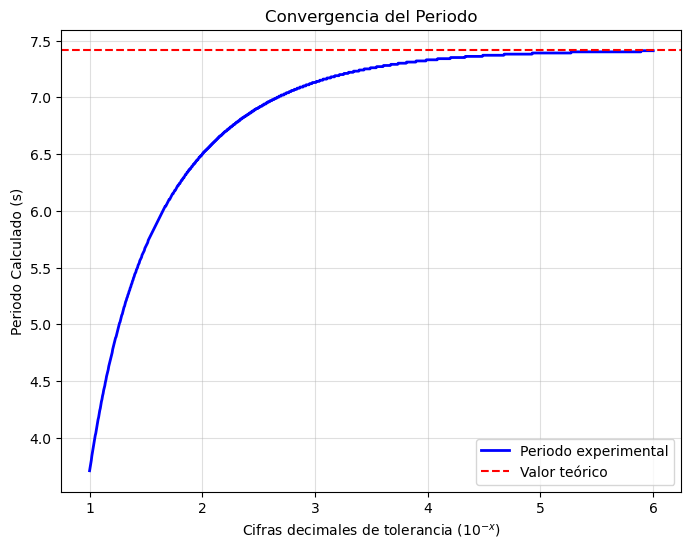

In [29]:
cifras_rango_tolerancia = np.linspace(1, 6, 1000) 

valores_periodos_experimentales = []
cifras_validas = []

# Umbral de seguridad: si el periodo detectado es > 20% del teórico, 
# es que se ha saltado el primer ciclo.
UMBRAL_ERROR = T_teorico * 1.2

for c in cifras_rango_tolerancia:
    p = calcular_periodo_oscilador_anarmonico(output_x, cifras_decimales_tolerancia=c)
    
    # 1. Encontró un valor (p is not None)
    # 2. El valor es coherente con una sola oscilación (p < UMBRAL_ERROR)
    if p is not None and p < UMBRAL_ERROR:
        valores_periodos_experimentales.append(p)
        cifras_validas.append(c)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.set_xlabel('Cifras decimales de tolerancia ($10^{-x}$)')
ax1.set_ylabel('Periodo Calculado (s)')

# Ahora cifras_validas y valores_periodos_experimentales SIEMPRE tendrán el mismo tamaño
ax1.plot(cifras_validas, valores_periodos_experimentales, color='blue', lw=2, label="Periodo experimental")
ax1.axhline(y=T_teorico, color='r', linestyle='--', label="Valor teórico")

ax1.set_title('Convergencia del Periodo')
ax1.grid(True, alpha=0.4)
ax1.legend()

plt.show()

### Aplicación de algoritmos para la resolución numérica de ecuaciones diferenciales

<p style="text-indent: 0em; text-align: justify;">En la práctica científica e ingenieril, la mayoría de las ecuaciones diferenciales ordinarias (EDO) no poseen una solución analítica en términos de funciones elementales. Por ello, recurrimos a métodos numéricos que aproximan la solución en un intervalo discreto de tiempo o espacio.

<p style="text-indent: 0em; text-align: justify;">Partimos habitualmente de un Problema de Valor Inicial (PVI) definido como:

$$\frac{dy}{dt} = f(t, y), \quad y(t_0) = y_0$$



#### Método de Euler para resolver EDOS
<p style="text-indent: 0em; text-align: justify;">Es el algoritmo más simple y sirve como base para entender los métodos de un solo paso. Se basa en la aproximación de la derivada mediante la serie de Taylor truncada al primer término.

$$y_{n+1} = y_n + \Delta t\cdot f(t_n, y_n)$$

Donde $\Delta t$ es el tamaño del paso ($\Delta t = t_{n+1} - t_n$). 

#### ¿Por qué transformar una EDO en un Sistema?

<p style="text-indent: 0em; text-align: justify;">A menudo, nos encontramos con ecuaciones que involucran aceleraciones ($x''$) o potencias superiores. Sin embargo, los métodos numéricos estándar trabajan sobre la forma estándar $y' = f(t, y)$. Para resolver esto, aplicamos la técnica de reducción de orden.

#### El proceso de derivación
<p style="text-indent: 0em; text-align: justify;">Partimos de una ley de ecuación simple:
    
$$x'(t) = x^2$$

<p style="text-indent: 0em; text-align: justify;">Si queremos ver cómo cambia la aceleración, derivamos respecto al tiempo usando la **regla de la cadena**:
    
$$\frac{d}{dt}(x'(t)) = \frac{d}{dt}(x^2) \implies x''(t) = 2x \cdot x'$$

<p style="text-indent: 0em; text-align: justify;">Como ya sabemos que $x' = x^2$, sustituimos para que todo quede en términos de $x$:
    
$$x''(t) = 2x(x^2) = 2x^3$$

#### Construcción del Sistema Equivalente
<p style="text-indent: 0em; text-align: justify;">Para que un ordenador pueda resolver esto, definimos una nueva variable de estado. Digamos que $v(t)$ es la velocidad. Esto nos permite "romper" una ecuación compleja en dos ecuaciones simples de primer orden. Así tomando:

$$v = x'$$

<p style="text-indent: 0em; text-align: justify;">Sabemos por la observación inmediatamente anterior que $$v' = x'' = 2x^3$$

<p style="text-indent: 0em; text-align: justify;">Esto nos da el sistema acoplado:
    
$$\begin{cases} 
x' = v \left(=x^2\right)\\ 
v' = 2x^3 
\end{cases}$$

<p style="text-indent: 0em; text-align: justify;">Cuando programamos esto, en cada instante $t_i$ de la partición de tiempo:
    
* Usamos el valor actual de $x_i$ para calcular el siguiente $x_{i+1}$ (usando $x^2$).
* Usamos el valor actual de $x_i$ para calcular el siguiente $v_{i+1}$ (usando $2x^3$).

<p style="text-indent: 0em; text-align: justify;">Esto es lo que permite que los algoritmos vectorizados resuelvan problemas físicos complejos (como órbitas planetarias).

#### Implementación del Algoritmo de Euler para la resolución de la EDO

<p style="text-indent: 0em; text-align: justify;">Utilizando las condiciones iniciales $x_0 = 0.1$ y $v_0 = x_0^2 = 0.01$, aplicamos el esquema de discretización con un paso de tiempo $\Delta t$:

1. $x(t_{i+1}) = x(t_i) + (x(t_i))^2 \cdot \Delta t$
2. $v(t_{i+1}) = v(t_i) + 2(x(t_i))^3 \cdot \Delta t$

#### Implementación Computacional: El Algoritmo de Euler modificado

$$\begin{cases} v_{i+1} = v_i + \frac{1}{m}F(x_i)\Delta t \\ x_{i+1} = x_i + v_{i+1}\Delta t \end{cases}$$



In [30]:
# VALORES INICIALES PARA RESOLVER LA EDO x' = x^2
x0 = 0.1
v0 = x0**2 
tinicial = 0
tfinal = 5
N = 1000  # Número de pasos
delta = (tfinal - tinicial) / N

# Definición de la "fuerza" o lado derecho de la ecuación de aceleración
# En nuestro caso, a = x'' = 2x^3, entonces F/m = 2x^3
def aceleracion(x_val):
    return 2 * (x_val**3)

# PROBLEMA DE VALORES INCIALES PVI
# x(0) = 0.1
# v(0) = 0.01
output_x_ec = [x0]
output_v_ec = [v0]

for i in range(N):
    aceleracion_actual = aceleracion(output_x_ec[i])
    vsiguiente = output_v_ec[i] + aceleracion_actual * delta
    xsiguiente = output_x_ec[i] + vsiguiente * delta
    output_x_ec.append(xsiguiente)
    output_v_ec.append(vsiguiente)

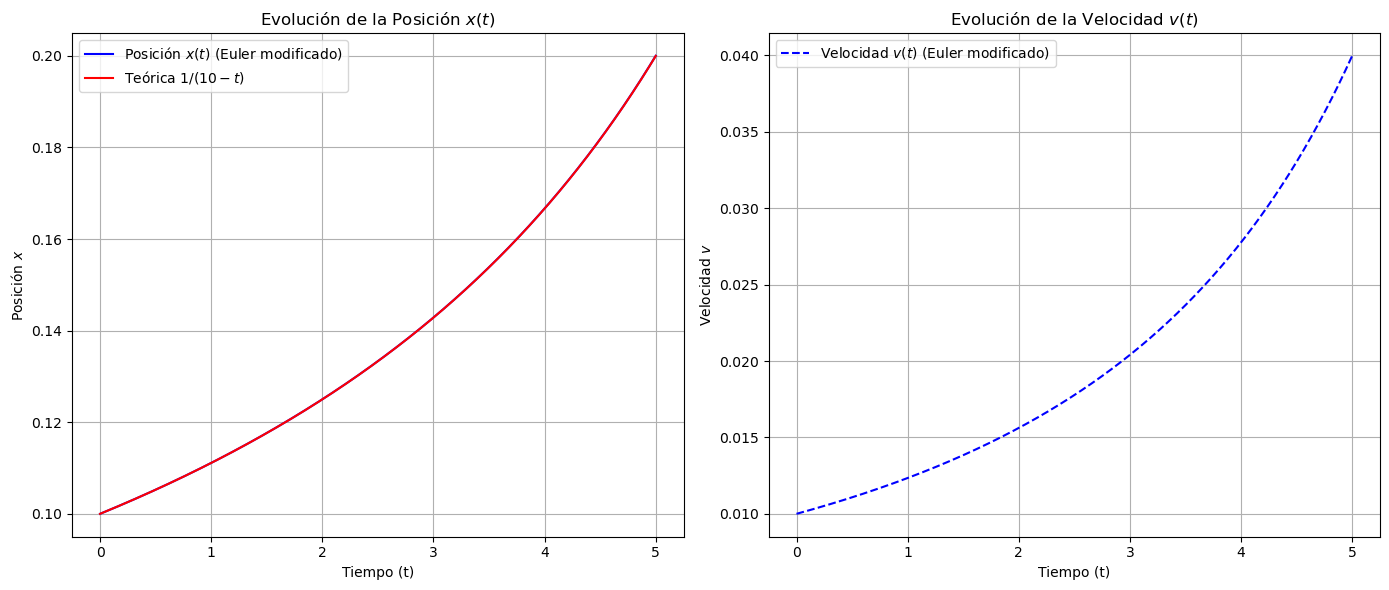

In [31]:
tiempo = np.linspace(tinicial, tfinal, len(output_x_ec))
posicion_teorica = 1 / (10 - tiempo)

plt.figure(figsize=(14, 6)) # Aumentamos el tamaño para que los gráficos se vean mejor

# Gráfico de Posición (x(t))
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(tiempo, output_x_ec, label='Posición $x(t)$ (Euler modificado)', color='blue')
plt.plot(tiempo, posicion_teorica, label='Teórica $1/(10-t)$', color='red')
plt.title('Evolución de la Posición $x(t)$')
plt.xlabel('Tiempo (t)')
plt.ylabel('Posición $x$')
plt.legend()
plt.grid(True)

# Gráfico de Velocidad (v(t))
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(tiempo, output_v_ec, "--", label='Velocidad $v(t)$ (Euler modificado)', color='blue')
plt.title('Evolución de la Velocidad $v(t)$')
plt.xlabel('Tiempo (t)')
plt.ylabel('Velocidad $v$')
plt.legend()
plt.grid(True)

plt.tight_layout() 
plt.show()

<p style="text-indent: 0em; text-align: justify;">En términos matemáticos, lo que hemos programado arriba es la resolución de un Problema de Valor Inicial. Este se define por el par ordenado de la ecuación diferencial y su estado inicial:

$$\begin{cases} 
\dfrac{dx}{dt} = v(t) \\ 
\dfrac{dv}{dt} = 2(x(t))^3 
\end{cases}$$

<p style="text-indent: 0em; text-align: justify;">Con las condiciones iniciales en $t_0 = 0$:

$$\begin{cases} 
x(0) = 0.1 \\ 
v(0) = 0.01 
\end{cases}$$

####  Resolución Analítica del problema de valores iniciales (PVI)

<p style="text-indent: 0em; text-align: justify;">Para validar nuestros resultados numéricos, resolvemos analíticamente la EDO de primer orden original mediante el método de separación de variables:

<p style="text-indent: 0em; text-align: justify;">Dada la ecuación:
    
$$\frac{dx}{dt} = x^2$$

<p style="text-indent: 0em; text-align: justify;">Separamos las variables $x$ y $t$:
    
$$\frac{dx}{x^2} = dt$$

Integramos en ambos lados:
$$\int \frac{1}{x^2} dx = \int dt \implies -\frac{1}{x} = t + C$$

Despejamos $x(t)$:
$$x(t) = \frac{-1}{t + C}$$

Para hallar la constante $C$, aplicamos la condición inicial $x(0) = 0.1$:
$$0.1 = \frac{-1}{0 + C} \implies C = \frac{-1}{0.1} = -10$$

Sustituyendo $C$, obtenemos la solución exacta:
$$x(t) = \frac{-1}{t - 10} = \frac{1}{10 - t}$$

<p style="text-indent: 0em; text-align: justify;">Esta resolución nos indica que el problema tiene una singularidad en el punto $t = 10$. Esto es una singularidad real del problema físico asociado a este problema de valores iniciales. De hecho, sí graficamos los valores hasta $t= 9.99 s$ vemos como la función $x$ se dispara al infinito.

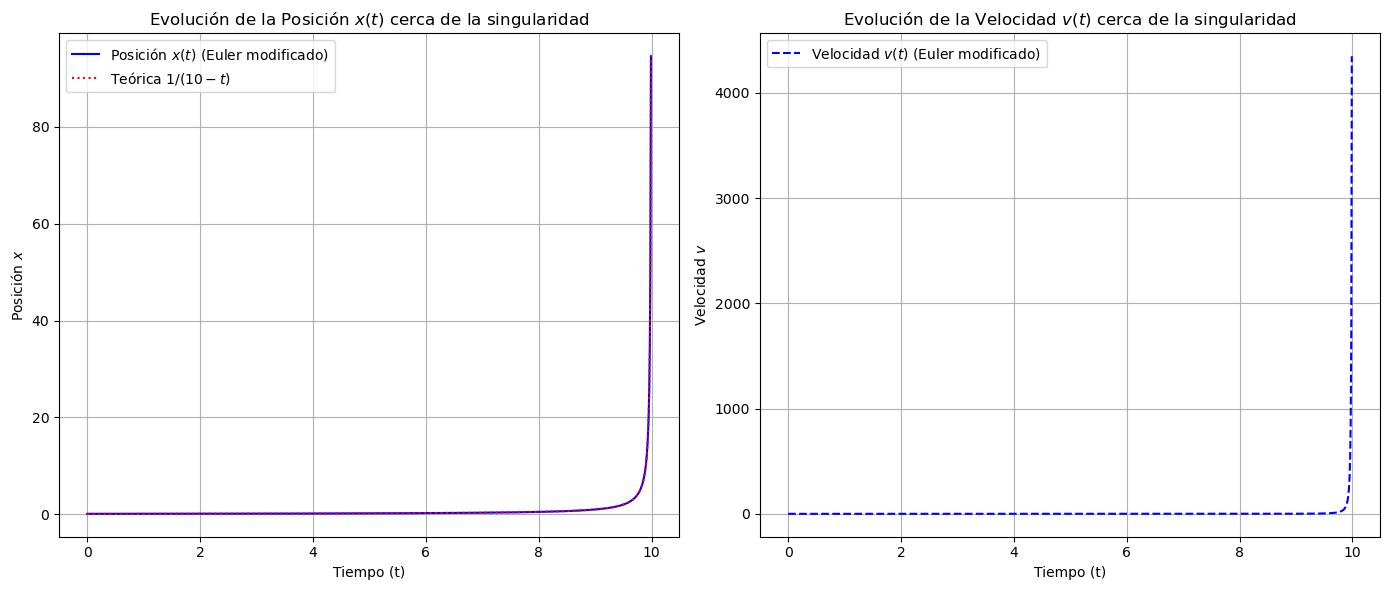

In [32]:
# VALORES INICIALES PARA RESOLVER LA EDO x' = x^2
x0 = 0.1
v0 = x0**2 
tinicial = 0
tfinal = 9.99
N = 1000  # Número de pasos
delta = (tfinal - tinicial) / N


# PROBLEMA DE VALORES INCIALES PVI
# x(0) = 0.1
# v(0) = 0.01
output_x_ec = [x0]
output_v_ec = [v0]

for i in range(N):
    aceleracion_actual = aceleracion(output_x_ec[i])
    vsiguiente = output_v_ec[i] + aceleracion_actual * delta
    xsiguiente = output_x_ec[i] + vsiguiente * delta
    output_x_ec.append(xsiguiente)
    output_v_ec.append(vsiguiente)

tiempo = np.linspace(tinicial, tfinal, len(output_x_ec))
posicion_teorica = 1 / (10 - tiempo)

plt.figure(figsize=(14, 6)) # Aumentamos el tamaño para que los gráficos se vean mejor

# Gráfico de Posición (x(t))
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(tiempo, output_x_ec, label='Posición $x(t)$ (Euler modificado)', color='blue')
plt.plot(tiempo, output_x_ec, label='Teórica $1/(10-t)$', color='red', linestyle=":")
plt.title('Evolución de la Posición $x(t)$ cerca de la singularidad')
plt.xlabel('Tiempo (t)')
plt.ylabel('Posición $x$')
plt.legend()
plt.grid(True)

# Gráfico de Velocidad (v(t))
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(tiempo, output_v_ec, "--", label='Velocidad $v(t)$ (Euler modificado)', color='blue')
plt.title('Evolución de la Velocidad $v(t)$ cerca de la singularidad')
plt.xlabel('Tiempo (t)')
plt.ylabel('Velocidad $v$')
plt.legend()
plt.grid(True)

plt.tight_layout() 
plt.show()

<p style="text-indent: 0em; text-align: justify;">En el modelado numérico, es vital distinguir entre un error del algoritmo y una propiedad intrínseca del sistema. El hecho de que nuestra solución analítica $x(t) = 1/(10-t)$ tienda a infinito en $t=10$ nos revela una singularidad real.

<p style="text-indent: 0em; text-align: justify;">Muchos fenómenos físicos —desde el colapso gravitatorio en un agujero negro hasta la ruptura de una gota de fluido o el crecimiento crítico de una población— presentan estas "catástrofes matemáticas". No son fallos del código; son umbrales donde las variables alcanzan valores infinitos en tiempo finito, indicando que el modelo clásico ha llegado a su límite. Aceptar estas singularidades es reconocer que la naturaleza posee puntos de discontinuidad donde las ecuaciones dejan de ser predictivas y el sistema experimenta un cambio de fase inevitable.

## Problema 3. Movimiento planetario

### Planteamiento teórico

Consideremos, en el espacio tridimensional dos cuerpos de masas $m_1$ y $m_2$ fijado un sistema de referencia y sean los vectorees $r_1$ y $r_2$ las posiciones de las particulas de masas $m_1$ y $m_2$ donde realmente estos son funciones

$$r_1, r_2 : \mathbb{R} \longrightarrow \mathbb{R}^3$$

Entonces, de la Ley de gravitación universal:

$$ma = F = -G \cdot \frac{m_1\cdot m_2}{r_{12}^2} \vec{u_{12}} $$

$$m_1 \cdot \frac{d^2 r_1}{dt} = - G \cdot \frac{m_1 \cdot m_2}{ |r_1 - r_2|^3 }(r_1 - r_2) \quad m_2 \cdot \frac{d^2 r_2}{dt} = - G \cdot \frac{m_1 \cdot m_2}{ |r_1 - r_2|^3 }(r_2 - r_1)$$

Pero como además, por la tercera ley de Newton (acción reacción) sabemos $F_{12} = - F{21}$, podemos buscar la posición del centro de masas y la posición relativa (dónde está una partícula tomando como origen la otra). Encontrar $r_1, r_2$ es equivalente a encontrar las funciones:

$$R = \frac{m_1 \cdot r_1 + m_2 \cdot r_2}{m_1 + m_2}\text{ (Centro de masas)   } \quad r = r_2 - r_1 \text{ (Posición relativa)}$$

Las ecuaciones entonces se transforman en:

$$R''(t) = 0$$

$$\mu \cdot r''(t) = - G \cdot \frac{m_1 \cdot m_2}{r^3}r \quad \text{ siendo: } \frac{1}{\mu} = \frac{1}{m_1} + \frac{1}{m_2} \iff  \mu = \frac{m_1\cdot m_2}{m_1 + m_2} \quad \mu \equiv\text{ "masa reducida"}$$

Como $R'' = 0$ la aceleración del centro de masas es cero, entonces el sistema es NO inercial y por tanto puedo centrar el sistema de referencias en el susodicho centro de masas (Sistema CM o SCM)

Como además $F(r(t))$ es paralela a $r(t)$, puedo expresar la fuerza como una fuerza central:

$$F(r) = f(r)\vec{r}$$

Por tanto, introduciendo la noción de momento angular:

$$ \vec{L} = \mu \cdot \vec{r}(t) \times \frac{d \vec{r} (t)}{dt}$$ 

Y por consiguiente:

$$\vec{r}(t)\cdot\vec{L}(t) = 0 \text { y } \frac{d\vec{ r}(t)}{dt} \cdot \vec{L}(t) = 0$$

Finalmente, podemos reorientar los ejes de forma que el eje $z$ lo tomamos en la dirección del momento angular. Por tanto, el movimiento ocurre solamente en el plano $\bar{xy}$. Con esta elección, el vector $\vec{r}(t)$ tiene de coordenadas:

$$\vec{r}(t) = \left(x(t), y(t), 0\right) \implies \vec{v}(t) = (v_x(t), v_y(t), 0)$$

Por consiguiente, hemos resumido el problema de seis incógnitas a dos incógnitas. Así, recordando la dependencia temporal 

$$x \equiv x(t) \quad y \equiv y(t)$$

Las ecuaciones serán:

$$\mu \cdot x'' = - G \cdot \frac{m_1\cdot m_2}{r^3}x \quad \text{   } \quad \mu \cdot y'' = - G \cdot \frac{m_1\cdot m_2}{r^3}y \text{ siendo:  } r := |\vec{r}(t)| = \sqrt{x^2 + y^2}$$

O equivalentemente:

$$\mu \cdot v_x' = - G \cdot \frac{m_1\cdot m_2}{\left(x^2 + y^2\right)^{\frac{3}{2}}}\cdot x \quad \text{   } \quad \mu \cdot v_y' = - G \cdot \frac{m_1\cdot m_2}{\left(x^2 + y^2\right)^{\frac{3}{2}}}\cdot y$$

### Implementación del algoritmo de Euler para la resolución del problema.

In [48]:
G = 6.67430e-11        # Constante de gravitación universal (m^3 / (kg s^2))

def calcular_mu(m1, m2):
    mu = (m1 * m2) / (m1 + m2)  # Masa reducida
    return mu

def movimiento_planetario(t0, tf, dt, x0, y0, vx0, vy0):
    N = int((tf - t0) / dt)
    
    t = np.linspace(t0, tf, N)
    x = np.zeros(N)
    y = np.zeros(N)
    vx = np.zeros(N)
    vy = np.zeros(N)

    x[0], y[0] = x0, y0
    vx[0], vy[0] = vx0, vy0

    for i in range(N - 1):
        # Cálculo del radio al cubo
        r3 = (x[i]**2 + y[i]**2)**1.5
        
        # Cálculo de la aceleración basada en la posición actual
        factor = -(G * m1 * m2) / (mu * r3)
        ax = factor * x[i]
        ay = factor * y[i]
        
        # 1º: Actualizamos la posición usando la velocidad ACTUAL
        # x(t + dt) = x(t) + v(t) * dt
        x[i+1] = x[i] + vx[i] * dt
        y[i+1] = y[i] + vy[i] * dt
        
        # 2º: Actualizamos la velocidad usando la aceleración ACTUAL
        # v(t + dt) = v(t) + a(t) * dt
        vx[i+1] = vx[i] + ax * dt
        vy[i+1] = vy[i] + ay * dt

    return x, y, vx, vy

In [49]:
# DATOS PARA EL MOVIMIENTO TIERRA-SOL

# Distancia media Tierra-Sol (1 Unidad Astronómica) en metros
AU = 1.495978707e11 

x0 = 1.0167 * AU       # Distancia en el afelio en metros
y0 = 0.0               
vx0 = 0.0              
vy0 = 29290.0          # Velocidad orbital aproximada en el afelio (m/s)

t0 = 0.0
tf = 365.25 * 24 * 3600    # Tiempo final: 1 año en segundos
dt = 360.0                 # Paso de tiempo: 1 hora (en segundos)

m1 = 1.989e30               # Masa del Sol (kg)
m2 = 5.972e24               # Masa de la Tierra (kg)
mu = calcular_mu(m1, m2)

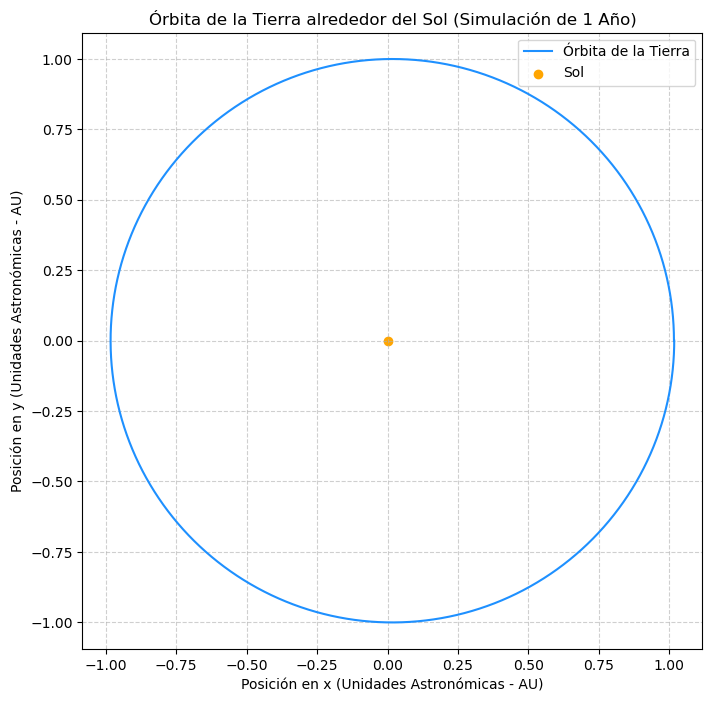

In [50]:
def graficar_movimiento_planetario(x, y, muchos_movimientos=False):
    x_AU = x / AU
    y_AU = y / AU

    plt.figure(figsize=(8, 8))
        
    plt.plot(x_AU, y_AU, label='Órbita de la Tierra', color='dodgerblue')
    
    # El Sol en el origen
    plt.scatter([0], [0], color='orange', marker='o', label='Sol')
    
    plt.title('Órbita de la Tierra alrededor del Sol (Simulación de 1 Año)')
    plt.xlabel('Posición en x (Unidades Astronómicas - AU)')
    plt.ylabel('Posición en y (Unidades Astronómicas - AU)')
    plt.axis('equal') # Mantiene la proporción real
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

x, y, vx, vy = movimiento_planetario(t0, tf, dt, x0, y0, vx0, vy0)
graficar_movimiento_planetario(x, y)
plt.show()

Podemos ver como el código es subjetivo a errores numéricos. Por ejemplo, si en vez de $dt=360$ tomamos $dt=36000$ (diez horas) vemos como el movimiento no es exactamente periódico:

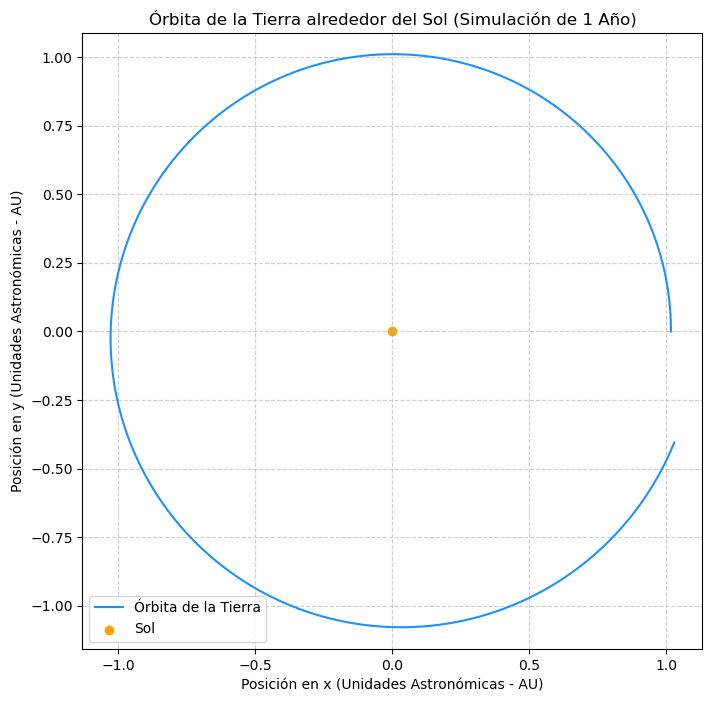

In [52]:
x_rota, y_rota, vx_rota, vy_rota = movimiento_planetario(t0, tf, 36000, x0, y0, vx0, vy0)
graficar_movimiento_planetario(x_rota,y_rota)

Para comprobar que el resultado se ciñe a la teoría, podemos comprobar que 
$$E = \frac{1}{2} \cdot m \cdot v^2 - G \frac{m_1 \cdot m_2}{r} \equiv \text{cte}$$

Así como que el momento angular es constante:

$$\vec{L} = (0,0, L_z) \implies L_z = \mu \cdot \left(x\cdot v_y - y \cdot v_x\right) \equiv \text{cte?}$$

In [56]:
def movimiento_planetario_fino(t0, tf, dt, x0, y0, vx0, vy0):
    """Usa Euler modificado en vez de Euler normal"""
    N = int((tf - t0) / dt)
    t = np.linspace(t0, tf, N)
    x, y = np.zeros(N), np.zeros(N)
    vx, vy = np.zeros(N), np.zeros(N)

    x[0], y[0], vx[0], vy[0] = x0, y0, vx0, vy0

    for i in range(N - 1):
        r3 = (x[i]**2 + y[i]**2)**1.5
        factor = -(G * m1 * m2) / (mu * r3) # Asegúrate de que m_sol y m_tierra coincidan con tus variables
        ax = factor * x[i]
        ay = factor * y[i]
        
        # ---  (Euler-Cromer) ---
        vx[i+1] = vx[i] + ax * dt
        vy[i+1] = vy[i] + ay * dt
        
        x[i+1] = x[i] + vx[i+1] * dt
        y[i+1] = y[i] + vy[i+1] * dt

    return x, y, vx, vy

In [59]:
import matplotlib.pyplot as plt

x, y, vx, vy = movimiento_planetario_fino(t0, tf, dt, x0, y0, vx0, vy0)
r = np.sqrt(x**2 + y**2)
v2 = vx**2 + vy**2

energia = 0.5 * mu * v2 - G * (m1 * m2) / r
momento_angular = mu * (x * vy - y * vx)

t_dias = np.linspace(t0, tf, len(x)) / (24 * 3600)


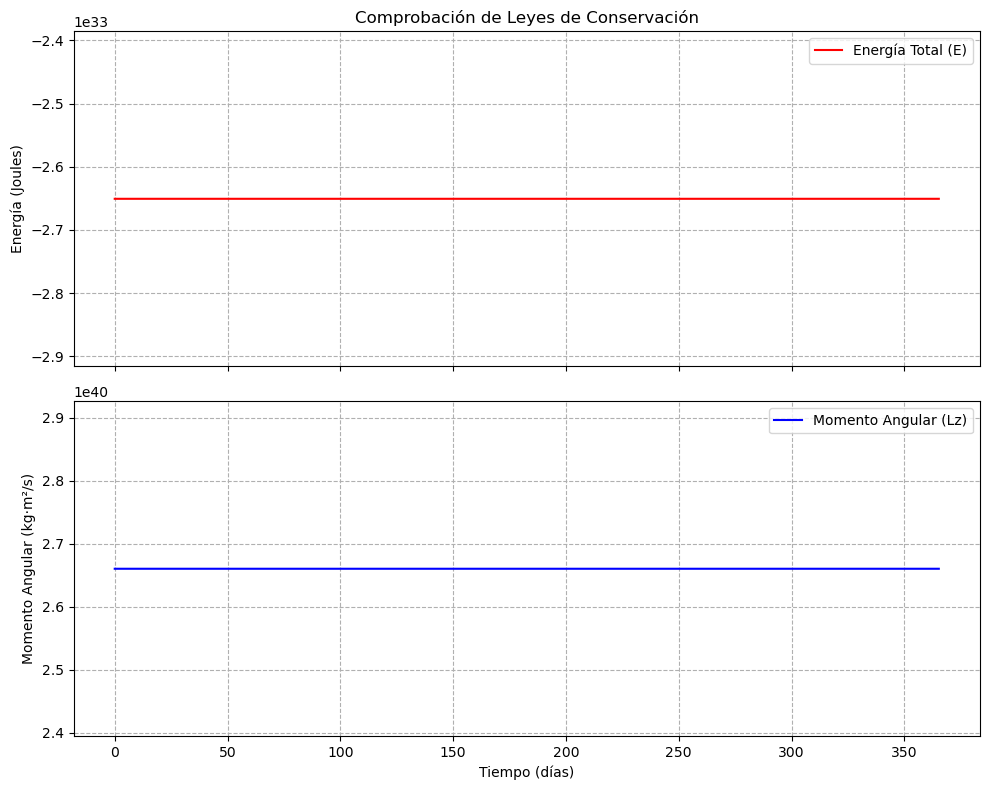

In [61]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfica de Energía
ax1.plot(t_dias, energia, color='red', label='Energía Total (E)')
ax1.set_ylabel('Energía (Joules)')
ax1.set_title('Comprobación de Leyes de Conservación')
ax1.grid(True, linestyle='--')
ax1.legend()

# Gráfica de Momento Angular
ax2.plot(t_dias, momento_angular, color='blue', label='Momento Angular (Lz)')
ax2.set_ylabel('Momento Angular (kg·m²/s)')
ax2.set_xlabel('Tiempo (días)')
ax2.grid(True, linestyle='--')
ax2.legend()

# Ajustamos los límites para que la escala sea razonable y no veamos el "ruido"
ax1.set_ylim(energia.min() * 1.1, energia.max() * 0.9) 
ax2.set_ylim(momento_angular.min() * 0.9, momento_angular.max() * 1.1)

plt.tight_layout()
plt.show()